# 5. EDA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency

In [2]:
# Load all train, validation, and test sets
X_train = np.load('../output/X_train.npy')
X_val = np.load('../output/X_val.npy')
X_test = np.load('../output/X_test.npy')

X_train_scaled = np.load('../output/X_train_scaled.npy')
X_val_scaled = np.load('../output/X_val_scaled.npy')
X_test_scaled = np.load('../output/X_test_scaled.npy')

y_train = np.load('../output/y_train.npy')
y_val = np.load('../output/y_val.npy')
y_test = np.load('../output/y_test.npy')

print("Data loaded successfully!")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Data loaded successfully!
X_train shape: (73926, 14), y_train shape: (73926, 10)
X_val shape: (24476, 14), y_val shape: (24476, 10)
X_test shape: (24521, 14), y_test shape: (24521, 10)


In [3]:
import json

# load feature names
with open("C:/Documents/VSCODE/Final FYP Code (ADESight)/ADR Data & Modelling Pipeline/output/feature_cols.json", "r") as f:
    feature_cols = json.load(f)

# load label names
with open("C:/Documents/VSCODE/Final FYP Code (ADESight)/ADR Data & Modelling Pipeline/output/reaction_cols.json", "r") as f:
    reaction_cols = json.load(f)

print(feature_cols)
print(reaction_cols)

['age_yrs_clean', 'num_drugs', 'sex_encoded', 'country_freq_encoded', 'drug_PREDNISONE', 'drug_DUPILUMAB', 'drug_RITUXIMAB', 'drug_METHOTREXATE', 'drug_INFLIXIMAB-DYYB', 'drug_VEDOLIZUMAB', 'drug_ACETAMINOPHEN', 'drug_TIRZEPATIDE', 'drug_TOCILIZUMAB', 'drug_INFLIXIMAB']
['reaction_DIARRHOEA', 'reaction_RASH', 'reaction_NAUSEA', 'reaction_DYSPNOEA', 'reaction_INFECTION', 'reaction_PSYCHIATRIC_EVENT', 'reaction_FATIGUE', 'reaction_DEATH', 'reaction_INJECTION_SITE_REACTION', 'reaction_HEADACHE']


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency

# ============================================================
# SETUP — reconstruct train DataFrame
# ============================================================

X_train_df = pd.DataFrame(X_train, columns=feature_cols).reset_index(drop=True)
y_train_df = pd.DataFrame(y_train, columns=reaction_cols).reset_index(drop=True)
train_df   = pd.concat([X_train_df, y_train_df], axis=1)

drug_cols     = [col for col in feature_cols if col.startswith('drug_')]
reaction_cols = [col for col in y_train_df.columns if col.startswith('reaction_')]

In [5]:
# ============================================================
# SECTION 1: BASIC INFO & DATA QUALITY 
# ============================================================
print("=== SECTION 1: BASIC INFO (train set)===")

print(train_df.info())
print("\n", train_df.head())

# caseid value counts (if present)
if 'caseid' in train_df.columns:
    print("\ncaseid value counts:")
    print(train_df['caseid'].value_counts())

# Missing values
print("\nMissing values:")
print(train_df.isnull().sum())

# Duplicates
duplicates = train_df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

=== SECTION 1: BASIC INFO (train set)===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73926 entries, 0 to 73925
Data columns (total 24 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   age_yrs_clean                     73926 non-null  float64
 1   num_drugs                         73926 non-null  float64
 2   sex_encoded                       73926 non-null  float64
 3   country_freq_encoded              73926 non-null  float64
 4   drug_PREDNISONE                   73926 non-null  float64
 5   drug_DUPILUMAB                    73926 non-null  float64
 6   drug_RITUXIMAB                    73926 non-null  float64
 7   drug_METHOTREXATE                 73926 non-null  float64
 8   drug_INFLIXIMAB-DYYB              73926 non-null  float64
 9   drug_VEDOLIZUMAB                  73926 non-null  float64
 10  drug_ACETAMINOPHEN                73926 non-null  float64
 11  drug_TIRZEPATIDE          


=== SECTION 2: CATEGORICAL FEATURES ===


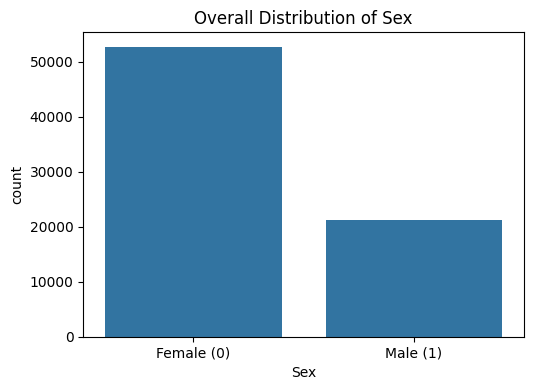

In [ ]:
# ============================================================
# SECTION 2: CATEGORICAL FEATURES (POST-ENCODING EDA)
# ============================================================
print("\n=== SECTION 2: CATEGORICAL FEATURES ===")

import matplotlib.pyplot as plt
import seaborn as sns

# Define your target column name here
TARGET_COL = 'target'  

# 1. Distribution of Sex (Binary Encoded)
if 'sex_encoded' in train_df.columns:
    plt.figure(figsize=(10, 4))
    
    # Left subplot: Overall distribution
    plt.subplot(1, 2, 1)
    ax = sns.countplot(data=train_df, x='sex_encoded')
    plt.title('Overall Distribution of Sex')
    plt.xlabel('Sex')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Female (0)', 'Male (1)'])
    
    # Right subplot: Relationship with the Target variable
    if TARGET_COL in train_df.columns:
        plt.subplot(1, 2, 2)
        ax2 = sns.countplot(data=train_df, x='sex_encoded', hue=TARGET_COL, palette='coolwarm')
        plt.title('Target Distribution by Sex')
        plt.xlabel('Sex')
        ax2.set_xticks([0, 1])
        ax2.set_xticklabels(['Female (0)', 'Male (1)'])
        
    plt.tight_layout()
    plt.show()


=== SECTION 3: DRUG FEATURES ===
drug_DUPILUMAB          27162.0
drug_TIRZEPATIDE        14130.0
drug_ACETAMINOPHEN      13876.0
drug_PREDNISONE         12761.0
drug_METHOTREXATE        6118.0
drug_RITUXIMAB           5956.0
drug_VEDOLIZUMAB         4803.0
drug_INFLIXIMAB          3902.0
drug_TOCILIZUMAB         3132.0
drug_INFLIXIMAB-DYYB     1559.0
dtype: float64


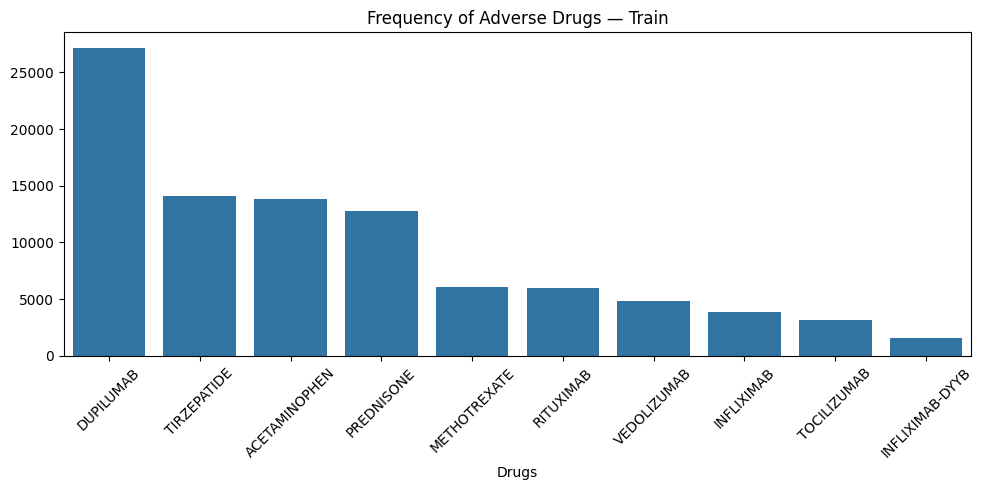

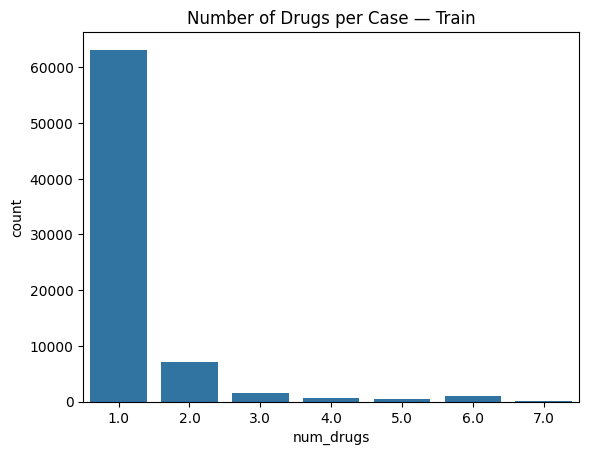


Drug Count Summary:
Mean drugs per case:       1.26
Median drugs per case:     1
Max drugs per case:        7
% cases with 1 drug:       85.5%
% cases with 2+ drugs:     14.5%


In [7]:
# ============================================================
# SECTION 3: DRUG FEATURES
# ============================================================
print("\n=== SECTION 3: DRUG FEATURES ===")

drug_counts = train_df[drug_cols].sum().sort_values(ascending=False)
print(drug_counts)

drug_counts_filtered = drug_counts[drug_counts.index != 'drug_combo']
cleaned_labels = [l.replace('drug_', '') for l in drug_counts_filtered.index]

plt.figure(figsize=(10, 5))
sns.barplot(x=cleaned_labels, y=drug_counts_filtered.values)
plt.xticks(rotation=45)
plt.xlabel('Drugs')
plt.title('Frequency of Adverse Drugs — Train')
plt.tight_layout()
plt.show()

# num_drugs per case
if 'num_drugs' in train_df.columns:
    num_drugs_col = train_df['num_drugs']
else:
    num_drugs_col = train_df[drug_cols].sum(axis=1)

plt.figure()
sns.countplot(x=num_drugs_col)
plt.title('Number of Drugs per Case — Train')
plt.show()

print(f"\nDrug Count Summary:")
print(f"Mean drugs per case:       {num_drugs_col.mean():.2f}")
print(f"Median drugs per case:     {num_drugs_col.median():.0f}")
print(f"Max drugs per case:        {num_drugs_col.max():.0f}")
print(f"% cases with 1 drug:       {(num_drugs_col == 1).sum() / len(train_df) * 100:.1f}%")
print(f"% cases with 2+ drugs:     {(num_drugs_col >= 2).sum() / len(train_df) * 100:.1f}%")


=== SECTION 4: NUMERICAL FEATURES ===


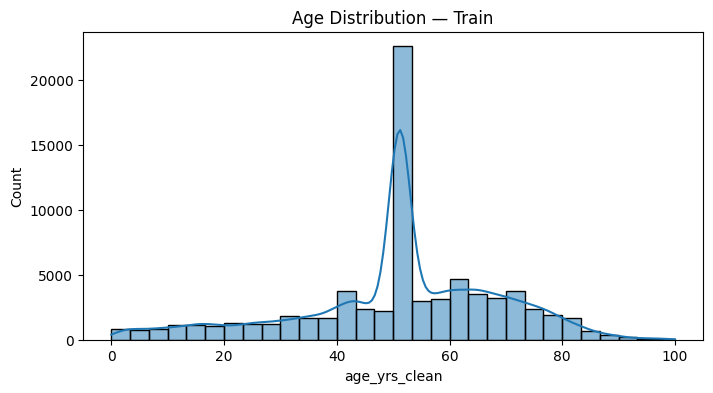

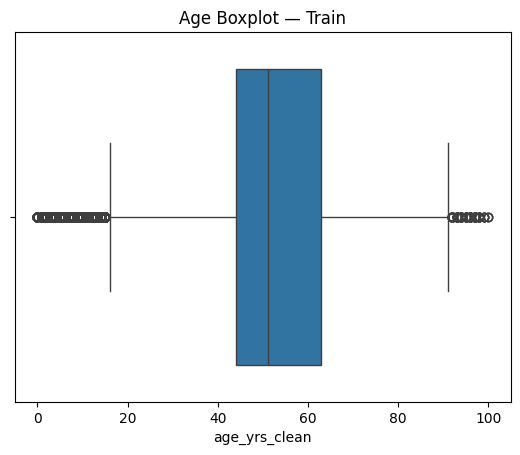

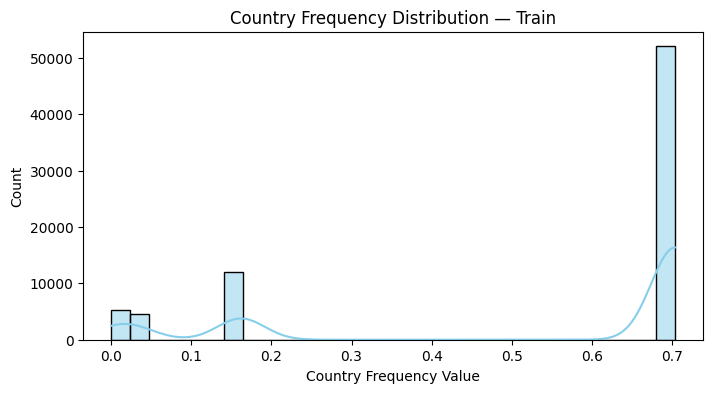

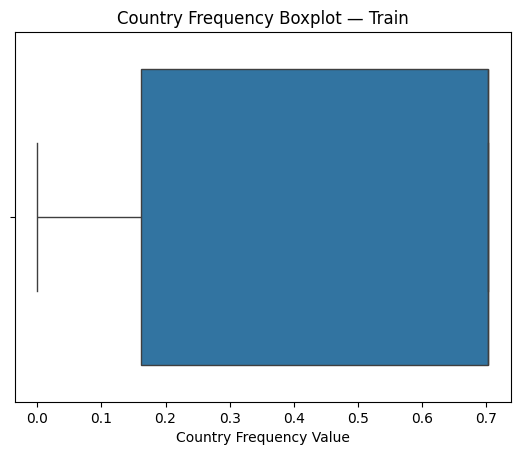

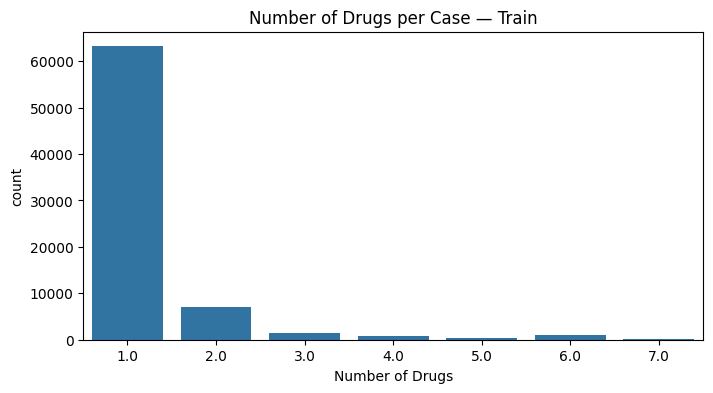

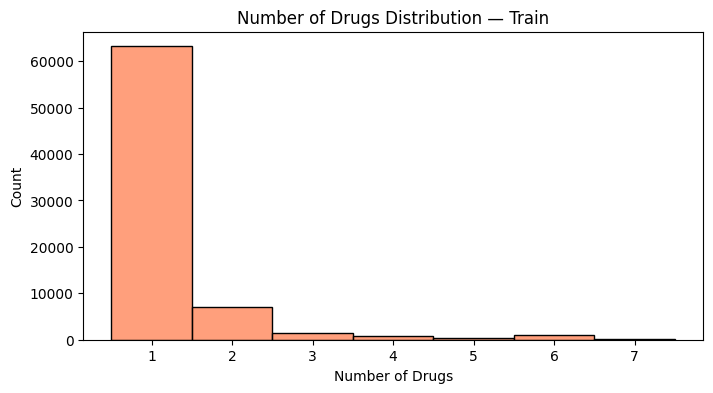


Drug Count Summary:
Mean drugs per case:       1.26
Median drugs per case:     1
Max drugs per case:        7
% cases with 1 drug:       85.5%
% cases with 2+ drugs:     14.5%


In [8]:
# ============================================================
# SECTION 4: NUMERICAL FEATURES (age, country frequency, num_drugs)
# ============================================================
print("\n=== SECTION 4: NUMERICAL FEATURES ===")

if 'age_yrs_clean' in train_df.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(train_df['age_yrs_clean'], bins=30, kde=True)
    plt.title('Age Distribution — Train')
    plt.show()

    plt.figure()
    sns.boxplot(x=train_df['age_yrs_clean'])
    plt.title('Age Boxplot — Train')
    plt.show()

if 'country_freq_encoded' in train_df.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(train_df['country_freq_encoded'], bins=30, kde=True, color='skyblue')
    plt.title('Country Frequency Distribution — Train')
    plt.xlabel('Country Frequency Value')
    plt.show()

    plt.figure()
    sns.boxplot(x=train_df['country_freq_encoded'])
    plt.title('Country Frequency Boxplot — Train')
    plt.xlabel('Country Frequency Value')
    plt.show()

# num_drugs per case
if 'num_drugs' in train_df.columns:
    num_drugs_col = train_df['num_drugs']
else:
    num_drugs_col = train_df[drug_cols].sum(axis=1)

plt.figure(figsize=(8, 4))
sns.countplot(x=num_drugs_col)
plt.title('Number of Drugs per Case — Train')
plt.xlabel('Number of Drugs')
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(num_drugs_col, bins=30, discrete=True, color='coral')
plt.title('Number of Drugs Distribution — Train')
plt.xlabel('Number of Drugs')
plt.show()

print(f"\nDrug Count Summary:")
print(f"Mean drugs per case:       {num_drugs_col.mean():.2f}")
print(f"Median drugs per case:     {num_drugs_col.median():.0f}")
print(f"Max drugs per case:        {num_drugs_col.max():.0f}")
print(f"% cases with 1 drug:       {(num_drugs_col == 1).sum() / len(train_df) * 100:.1f}%")
print(f"% cases with 2+ drugs:     {(num_drugs_col >= 2).sum() / len(train_df) * 100:.1f}%")


=== SECTION 5: REACTION ANALYSIS ===
reaction_INJECTION_SITE_REACTION    19928
reaction_INFECTION                  15842
reaction_RASH                       14533
reaction_NAUSEA                     10051
reaction_FATIGUE                     9643
reaction_DIARRHOEA                   9092
reaction_HEADACHE                    7933
reaction_DYSPNOEA                    7679
reaction_PSYCHIATRIC_EVENT           6434
reaction_DEATH                       2510
dtype: int64


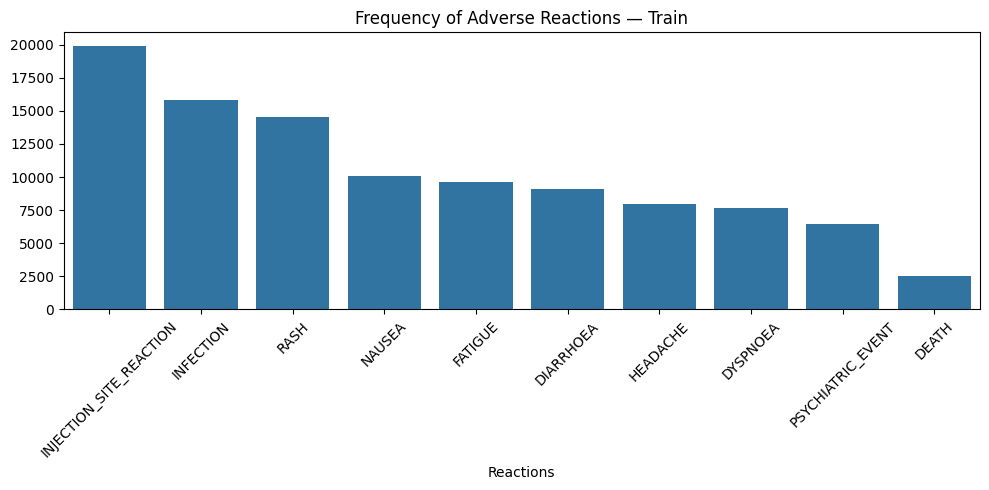

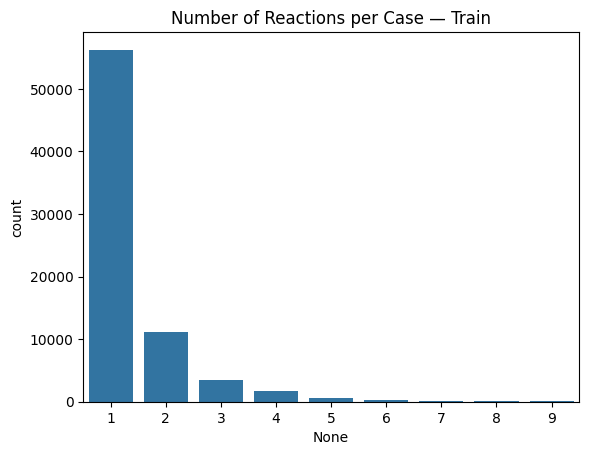

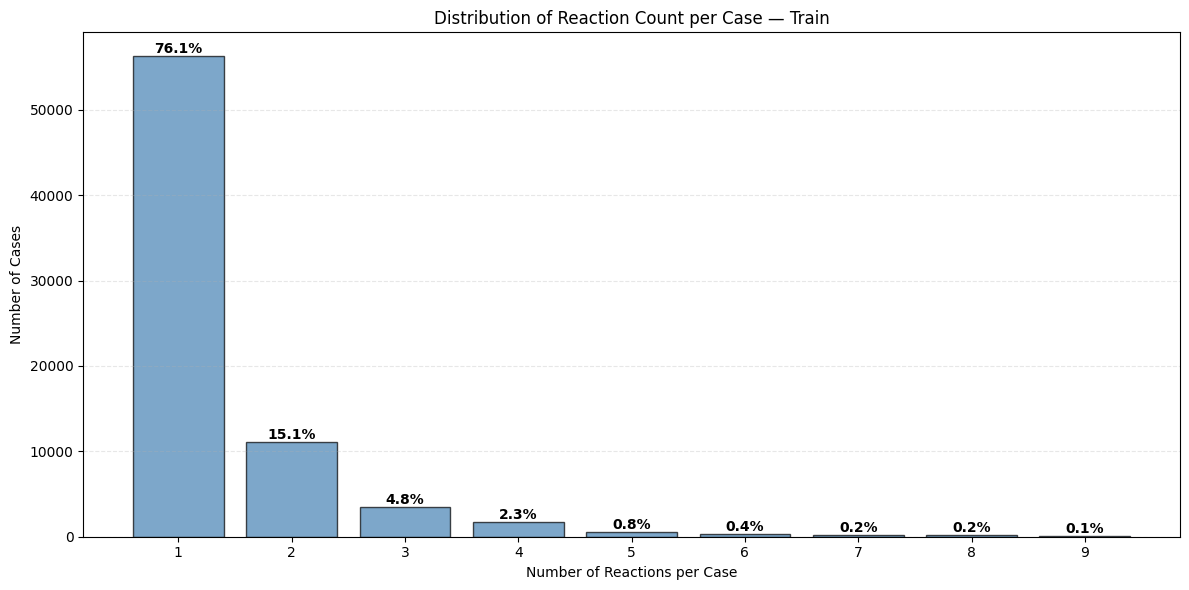


Reaction Count Summary:
Mean reactions per case:   1.40
Median reactions per case: 1
Max reactions per case:    9
% cases with 0 reactions:  0.0%
% cases with 3+ reactions: 8.8%

Number of cases with zero reactions: 0
Percentage of total records: 0.00%


In [9]:
# ============================================================
# SECTION 5: TARGET (REACTION) ANALYSIS
# ============================================================
print("\n=== SECTION 5: REACTION ANALYSIS ===")

# Reaction frequency bar plot
reaction_counts = train_df[reaction_cols].sum().sort_values(ascending=False)
print(reaction_counts)

reaction_counts_filtered = reaction_counts[reaction_counts.index != 'reaction_combo']
cleaned_labels = [l.replace('reaction_', '') for l in reaction_counts_filtered.index]

plt.figure(figsize=(10, 5))
sns.barplot(x=cleaned_labels, y=reaction_counts_filtered.values)
plt.xticks(rotation=45)
plt.xlabel('Reactions')
plt.title('Frequency of Adverse Reactions — Train')
plt.tight_layout()
plt.show()

# num_reactions per case — simple countplot
num_reactions = train_df[reaction_cols].sum(axis=1)
plt.figure()
sns.countplot(x=num_reactions)
plt.title('Number of Reactions per Case — Train')
plt.show()

# Reaction count bar chart with % labels (detailed version)
reaction_count_dist = num_reactions.value_counts().sort_index()
total_cases = len(train_df)

plt.figure(figsize=(12, 6))
bars = plt.bar(reaction_count_dist.index, reaction_count_dist.values,
               color='steelblue', edgecolor='black', alpha=0.7)

for count, freq in reaction_count_dist.items():
    percentage = (freq / total_cases) * 100
    plt.text(count, freq, f'{percentage:.1f}%',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel('Number of Reactions per Case')
plt.ylabel('Number of Cases')
plt.title('Distribution of Reaction Count per Case — Train')
plt.xticks(reaction_count_dist.index)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print(f"\nReaction Count Summary:")
print(f"Mean reactions per case:   {num_reactions.mean():.2f}")
print(f"Median reactions per case: {num_reactions.median():.0f}")
print(f"Max reactions per case:    {num_reactions.max():.0f}")
print(f"% cases with 0 reactions:  {(num_reactions == 0).sum() / total_cases * 100:.1f}%")
print(f"% cases with 3+ reactions: {(num_reactions >= 3).sum() / total_cases * 100:.1f}%")

# Zero-reaction check
num_no_reactions = (num_reactions == 0).sum()
print(f"\nNumber of cases with zero reactions: {num_no_reactions}")
print(f"Percentage of total records: {num_no_reactions / total_cases * 100:.2f}%")



=== SECTION 6: ASSOCIATION HEATMAPS ===


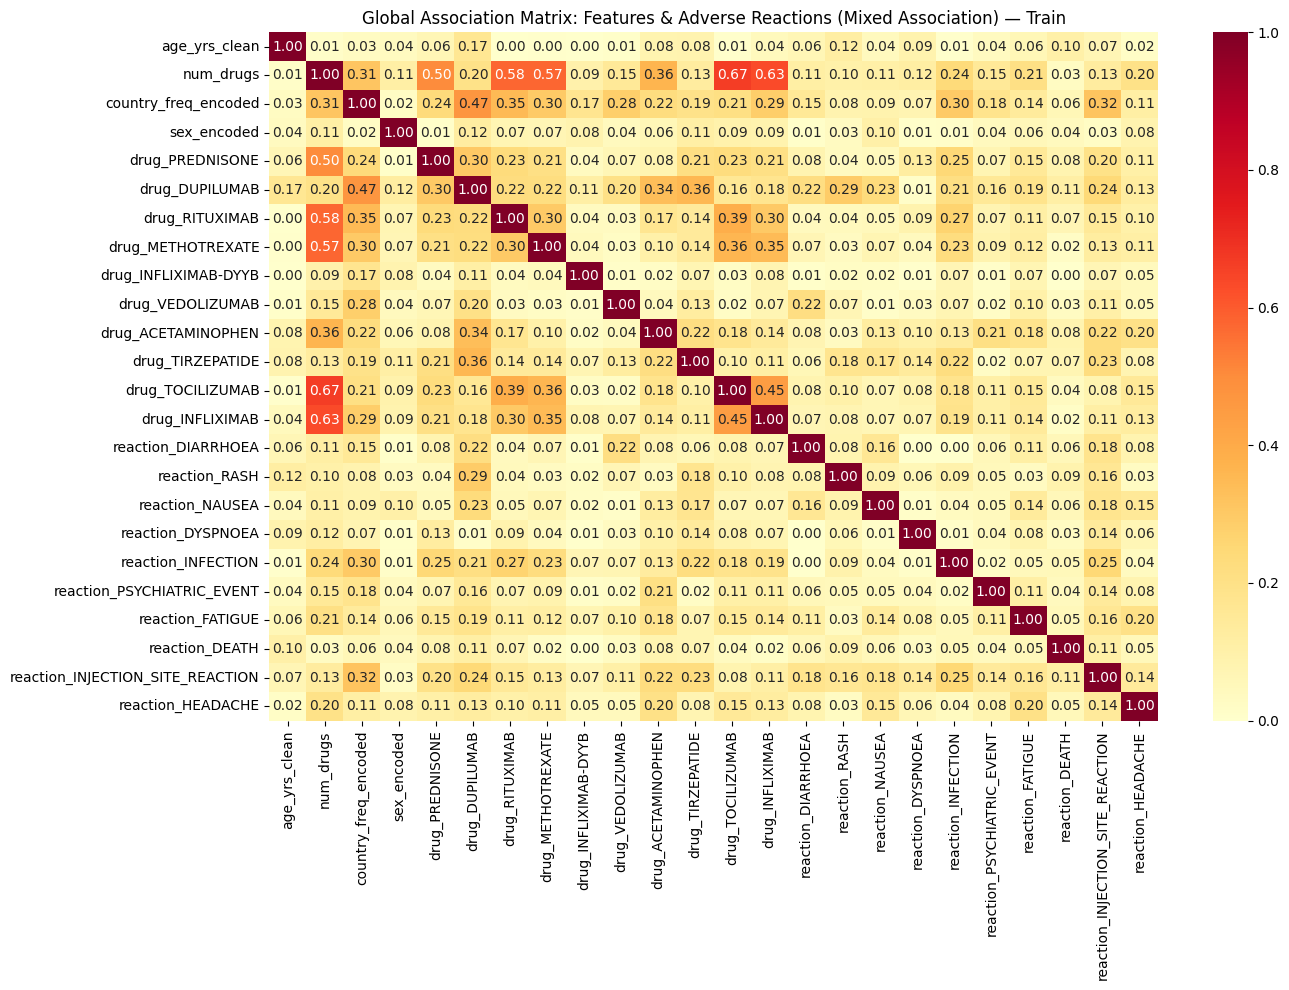

In [10]:
# ============================================================
# SECTION 6: ASSOCIATION HEATMAPS
# ============================================================
print("\n=== SECTION 6: ASSOCIATION HEATMAPS ===")

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    if confusion_matrix.empty: return 0
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    denom = min((kcorr-1), (rcorr-1))
    if denom <= 0: return 0
    return np.sqrt(phi2corr / denom)

def correlation_ratio(numeric_col, categorical_col):
    valid_idx = numeric_col.notna() & categorical_col.notna()
    num = numeric_col[valid_idx]
    cat = categorical_col[valid_idx]
    if len(num) == 0: return 0
    overall_mean = num.mean()
    total_ss = np.sum((num - overall_mean) ** 2)
    if total_ss == 0: return 0
    between_ss = sum(
        len(num[cat == c]) * (num[cat == c].mean() - overall_mean) ** 2
        for c in cat.unique()
    )
    return np.sqrt(between_ss / total_ss)

def mixed_association(col1, col2, numeric_cols):
    is_num1 = col1.name in numeric_cols
    is_num2 = col2.name in numeric_cols
    if is_num1 and is_num2:
        valid = col1.notna() & col2.notna()
        if valid.sum() < 2: return 0
        return abs(col1[valid].corr(col2[valid], method='spearman'))
    elif is_num1 and not is_num2:
        return correlation_ratio(col1, col2)
    elif not is_num1 and is_num2:
        return correlation_ratio(col2, col1)
    else:
        return cramers_v(col1, col2)

numeric_features     = [c for c in ['age_yrs_clean', 'num_drugs', 'country_freq_encoded'] if c in train_df.columns]
categorical_features = [c for c in ['sex_encoded'] + drug_cols if c in train_df.columns]
numeric_col_names    = set(numeric_features)

# --- Mixed association (numeric + categorical + reactions) ---
all_cols_mixed = numeric_features + categorical_features + reaction_cols
rows = []
for var1 in all_cols_mixed:
    rows.append([
        mixed_association(train_df[var1], train_df[var2], numeric_col_names)
        for var2 in all_cols_mixed
    ])

association_df_mixed = pd.DataFrame(rows, index=all_cols_mixed, columns=all_cols_mixed)

plt.figure(figsize=(14, 10))
sns.heatmap(association_df_mixed, annot=True, fmt=".2f", cmap='YlOrRd',
            xticklabels=all_cols_mixed, yticklabels=all_cols_mixed)
plt.title("Global Association Matrix: Features & Adverse Reactions (Mixed Association) — Train")
plt.tight_layout()
plt.show()


=== SECTION 7: SPLIT QUALITY CHECK ===
                                   Train     Val    Test  Train-Val Diff  \
reaction_DIARRHOEA                0.1230  0.1238  0.1236          0.0008   
reaction_RASH                     0.1966  0.1979  0.1975          0.0013   
reaction_NAUSEA                   0.1360  0.1369  0.1366          0.0009   
reaction_DYSPNOEA                 0.1039  0.1046  0.1044          0.0007   
reaction_INFECTION                0.2143  0.2157  0.2154          0.0014   
reaction_PSYCHIATRIC_EVENT        0.0870  0.0876  0.0875          0.0006   
reaction_FATIGUE                  0.1304  0.1314  0.1311          0.0009   
reaction_DEATH                    0.0340  0.0342  0.0341          0.0002   
reaction_INJECTION_SITE_REACTION  0.2696  0.2714  0.2709          0.0018   
reaction_HEADACHE                 0.1073  0.1080  0.1078          0.0007   

                                  Train-Test Diff  
reaction_DIARRHOEA                         0.0006  
reaction_RASH      

<Figure size 1200x500 with 0 Axes>

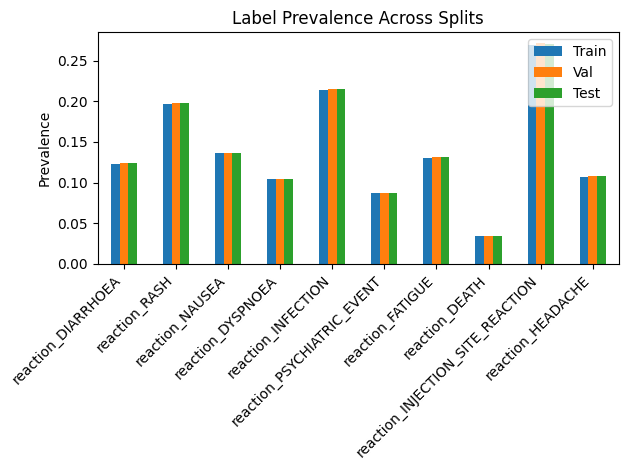

In [11]:
# ============================================================
# SECTION 7: SPLIT QUALITY CHECK
# ============================================================
print("\n=== SECTION 7: SPLIT QUALITY CHECK ===")

y_train_arr = np.array(y_train)
y_val_arr   = np.array(y_val)
y_test_arr  = np.array(y_test)

split_check = pd.DataFrame({
    "Train": y_train_arr.mean(axis=0),
    "Val":   y_val_arr.mean(axis=0),
    "Test":  y_test_arr.mean(axis=0),
}, index=reaction_cols)

split_check["Train-Val Diff"]  = abs(split_check["Train"] - split_check["Val"])
split_check["Train-Test Diff"] = abs(split_check["Train"] - split_check["Test"])

print(split_check.round(4))

plt.figure(figsize=(12, 5))
split_check[["Train", "Val", "Test"]].plot(kind="bar")
plt.title("Label Prevalence Across Splits")
plt.ylabel("Prevalence")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()